# protGPS on CMC (COSMIC Cancer Mutation Census): condensate localization variant effects

Same analysis as `protgps_clinvar_exploration.ipynb`, applied to the CMC somatic mutation set. Loads the merged wild-type vs. mutant protGPS predictions (`cmc_protgps_deltas.tsv`, built by `../12_variant_effect_prediction/localization_condensate/`).

**Data file is not checked into git** — regenerate via the pipeline in `12_variant_effect_prediction/localization_condensate/`, or pull `cmc_protgps_deltas.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

Note: CMC uses Ensembl transcript IDs (`ENST...`), not RefSeq (`NM_...`) like ClinVar — different accession namespace, same gene symbols where they overlap.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

COMPARTMENTS = [
    "NUCLEAR_SPECKLE", "P-BODY", "PML-BDOY", "POST_SYNAPTIC_DENSITY",
    "STRESS_GRANULE", "CHROMOSOME", "NUCLEOLUS", "NUCLEAR_PORE_COMPLEX",
    "CAJAL_BODY", "RNA_GRANULE", "CELL_JUNCTION", "TRANSCRIPTIONAL",
]

## Load data

In [2]:
df = pd.read_csv("cmc_protgps_deltas.tsv", sep="\t")
print(f"{len(df):,} variant rows")
df.head()

4,190,344 variant rows


,GENOMIC_MUTATION_ID,GENE_NAME,accession,category,WT_NUCLEAR_SPECKLE,WT_P-BODY,WT_PML-BDOY,WT_POST_SYNAPTIC_DENSITY,WT_STRESS_GRANULE,WT_CHROMOSOME,...,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
0,COSV66112854,CDKL5,ENST00000379989,missense,0.0,0.0036,0.0,0.0,0.0,0.0621,...,0.0,0.0,0.0,0.0018,0.0000,0.0,0.0,0.0,-0.0158,0.0
1,COSV66110116,CDKL5,ENST00000379989,missense,0.0,0.0036,0.0,0.0,0.0,0.0621,...,0.0,0.0,0.0,-0.0046,-0.0001,0.0,0.0,0.0,-0.0055,0.0
2,COSV66113302,CDKL5,ENST00000379989,missense,0.0,0.0036,0.0,0.0,0.0,0.0621,...,0.0,0.0,0.0,0.0256,-0.0001,0.0,0.0,0.0,-0.0090,0.0
3,COSV66110478,CDKL5,ENST00000379989,missense,0.0,0.0036,0.0,0.0,0.0,0.0621,...,0.0,0.0,0.0,0.0068,0.0000,0.0,0.0,0.0,0.0095,0.0
4,COSV66110166,CDKL5,ENST00000379989,missense,0.0,0.0036,0.0,0.0,0.0,0.0621,...,0.0,0.0,0.0,-0.0067,-0.0001,0.0,0.0,0.0,-0.0428,0.0


## Sanity check: same known condensate marker genes as the ClinVar notebook

Same five genes, looked up via their CMC/Ensembl transcript IDs this time. Should reproduce the same pattern seen in ClinVar (4/5 correct, NPM1 mismatched) since it's the same WT protein sequence and the same model -- a useful cross-dataset consistency check.

In [3]:
known_genes = {
    "COIL": ("ENST00000240316", "CAJAL_BODY"),
    "FUS": ("ENST00000254108", "STRESS_GRANULE"),
    "G3BP1": ("ENST00000394123", "STRESS_GRANULE"),
    "NPM1": ("ENST00000296930", "NUCLEOLUS"),
    "TARDBP": ("ENST00000240185", "STRESS_GRANULE"),
}

wt_cols = [f"WT_{c}" for c in COMPARTMENTS]
for gene, (acc, expected) in known_genes.items():
    rows = df[df["accession"] == acc]
    if rows.empty:
        print(f"{gene} ({acc}): no variant rows in this table")
        continue
    wt_scores = rows.iloc[0][wt_cols]
    top = wt_scores.astype(float).idxmax().replace("WT_", "")
    top_score = wt_scores.astype(float).max()
    match = "OK" if top == expected else "MISMATCH"
    print(f"{gene:8s} ({acc}): top={top:22s} ({top_score:.3f})  expected={expected:15s}  [{match}]")

COIL     (ENST00000240316): top=CAJAL_BODY             (0.992)  expected=CAJAL_BODY       [OK]
FUS      (ENST00000254108): top=STRESS_GRANULE         (0.874)  expected=STRESS_GRANULE   [OK]


G3BP1    (ENST00000394123): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]
NPM1     (ENST00000296930): top=STRESS_GRANULE         (0.998)  expected=NUCLEOLUS        [MISMATCH]


TARDBP   (ENST00000240185): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]


## Wild-type score distributions

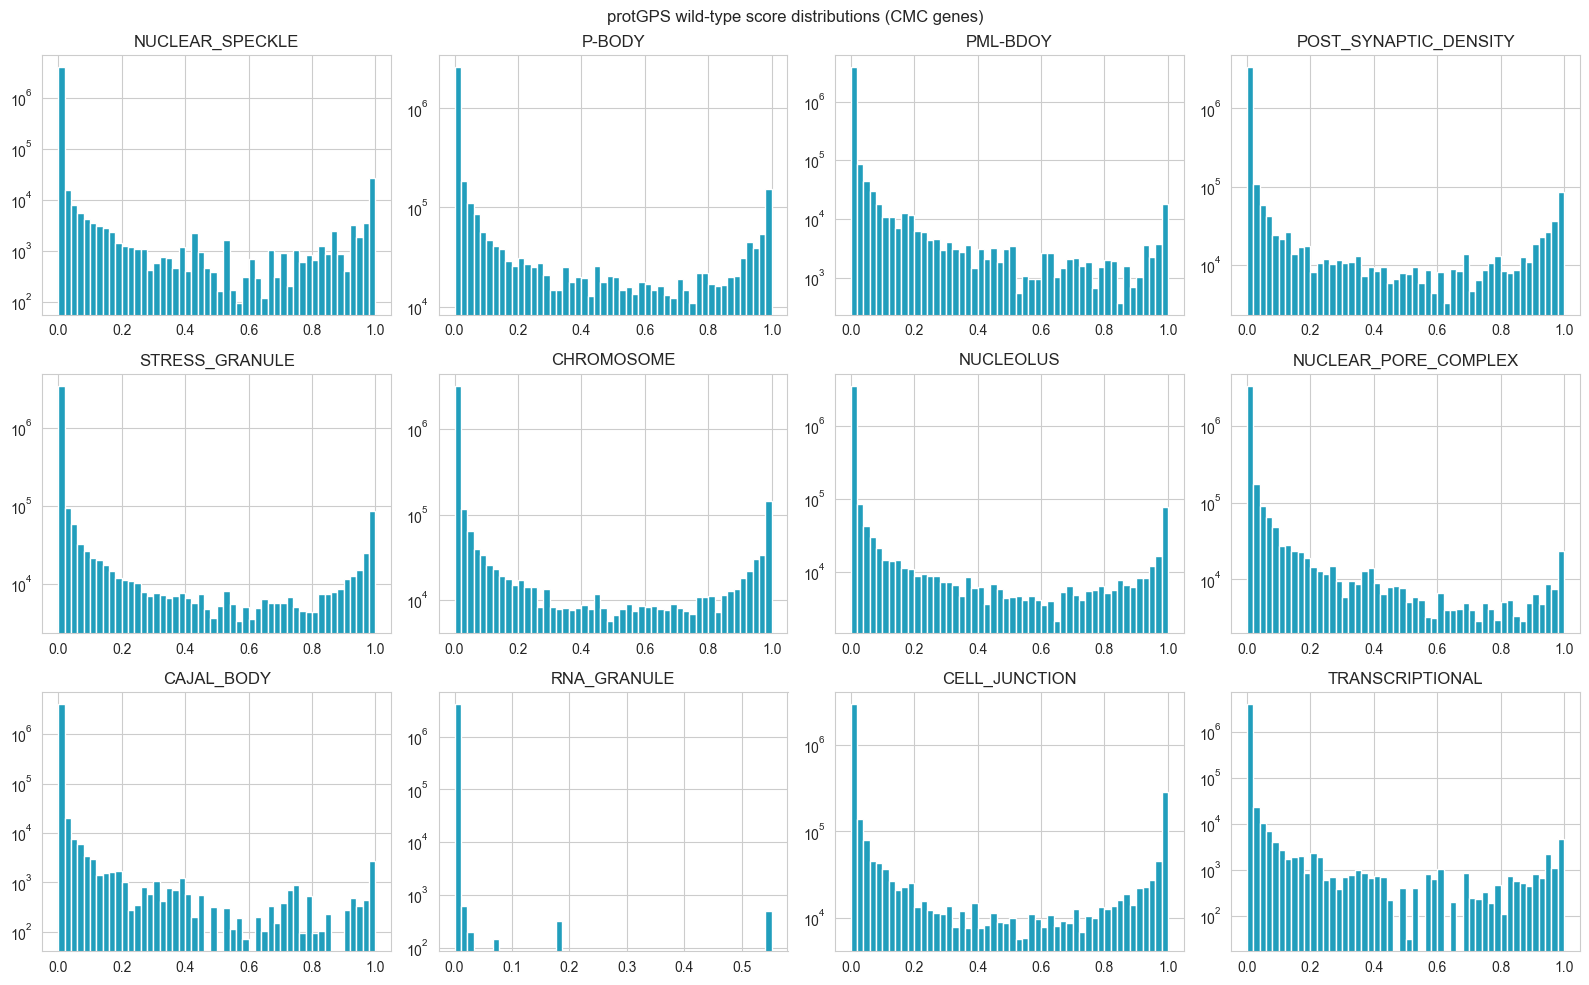

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"WT_{c}"], bins=50, color="#219ebc")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS wild-type score distributions (CMC genes)")
fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

Somatic cancer mutations (CMC) vs. germline ClinVar variants -- worth comparing whether the delta distributions look similar in shape/magnitude between the two notebooks.

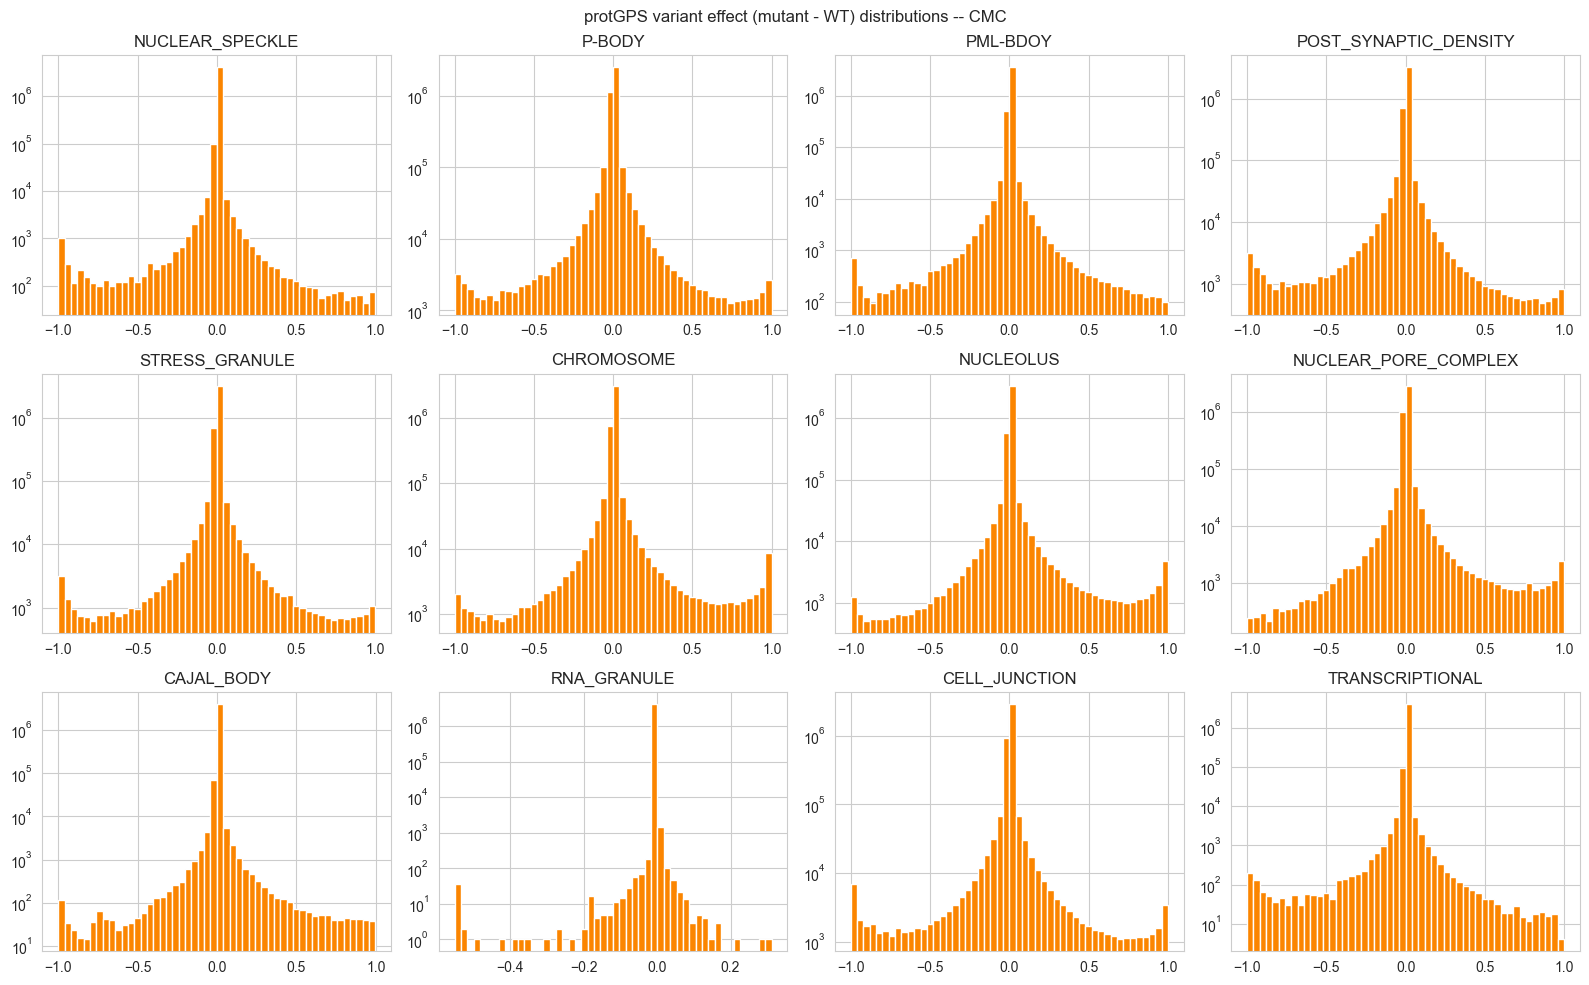

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"DELTA_{c}"], bins=50, color="#fb8500")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS variant effect (mutant - WT) distributions -- CMC")
fig.tight_layout()
plt.show()

## Variants with the largest predicted condensate-localization change

In [6]:
delta_cols = [f"DELTA_{c}" for c in COMPARTMENTS]
max_abs_delta = df[delta_cols].abs().max(axis=1)
top_variants = df.loc[max_abs_delta.sort_values(ascending=False).index[:25]]
top_variants[["GENOMIC_MUTATION_ID", "GENE_NAME", "category", "accession"] + delta_cols].head(25)

,GENOMIC_MUTATION_ID,GENE_NAME,category,accession,DELTA_NUCLEAR_SPECKLE,DELTA_P-BODY,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
3503896,COSV52917968,SH3RF1,nonsense,ENST00000284637,0.0000,-0.0007,0.0000,0.0000,0.0000,0.0065,1.0000,0.0000,0.0000,0.0,-0.9995,0.0000
2616581,COSV55727445,CDH1,nonsense,ENST00000261769,0.0207,0.0000,0.0000,0.0000,0.0000,0.8922,0.0016,0.0000,0.0000,0.0,-1.0000,0.0000
2616560,COSV55731518,CDH1,nonsense,ENST00000261769,0.0002,0.0020,0.0005,0.0000,0.0755,0.8282,0.0000,0.0004,0.0000,0.0,-1.0000,0.0009
2616520,COSV55730999,CDH1,nonsense,ENST00000261769,0.0000,0.0000,0.0000,0.0000,0.0005,1.0000,0.0000,0.0092,0.0000,0.0,-1.0000,0.0000
2616501,COSV55737132,CDH1,nonsense,ENST00000261769,0.0002,0.0154,0.0000,0.0000,0.0000,0.9670,0.1083,0.0000,0.0000,0.0,-1.0000,0.0000
2616477,COSV55730078,CDH1,nonsense,ENST00000261769,0.0000,0.7025,0.0008,0.0000,0.7730,0.0646,0.0000,0.0000,0.0000,0.0,-1.0000,0.0047
2616475,COSV113909281,CDH1,nonsense,ENST00000261769,0.0020,0.0000,0.0000,0.0000,0.0000,0.9972,0.0004,0.0000,0.0000,0.0,-1.0000,0.0000
2616452,COSV55737302,CDH1,nonsense,ENST00000261769,0.0000,0.0001,0.0000,0.0000,0.0000,1.0000,0.0001,0.0121,0.0000,0.0,-1.0000,0.0000
15675,COSV55761365,KDR,nonsense,ENST00000263923,0.0000,0.0009,0.0000,0.0000,0.0000,0.0164,0.9997,0.0001,0.0000,0.0,-1.0000,0.0000
1501587,COSV107385368,SFTPC,nonsense,ENST00000318561,0.0000,0.9080,0.0000,0.0000,0.0000,0.0064,0.0000,0.5788,0.0000,0.0,-1.0000,0.0000
